# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1, 2026-2027 — Major Project**

**Objective:** Analyze agricultural data across seasons (Kharif, Rabi, Zaid) to identify seasonal patterns, trends, relationships and differences in agricultural performance.

**Dataset:** `seasonal_agriculture_performance_dataset.csv` — 4000 farm records, 8 states, 8 crops, 3 seasons.


## 1. Setup and Data Loading

In [1]:
# Run this cell first if any library is missing
# !pip install pandas numpy matplotlib seaborn scipy


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 40)

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print('Shape:', df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Exploring the Dataset

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [5]:
for col in ['State', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"{col}: {df[col].nunique()} unique -> {df[col].unique()}")


State: 8 unique -> <StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str
Crop: 8 unique -> <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Season: 3 unique -> <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Irrigation_Method: 4 unique -> <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


## 3. Data Cleaning

Checking missing values and duplicates, then imputing missing values using the median for the same Season + Crop group (keeps values realistic for that growing condition).

In [6]:
print(df.isnull().sum()[df.isnull().sum() > 0])
print('Duplicate rows:', df.duplicated().sum())


Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64
Duplicate rows: 0


In [7]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))
df.fillna(df.median(numeric_only=True), inplace=True)

print('Remaining missing values:', df.isnull().sum().sum())


Remaining missing values: 0


**Extreme yield values check** — some Yield_Tonnes_Ha values look very high (up to ~100). Verified against `Production_Tonnes = Yield × Area`, and the values are internally consistent, so they are genuine (mostly Sugarcane) rather than data errors — kept as is.

In [8]:
diff = (df['Yield_Tonnes_Ha'] * df['Farm_Area_Hectares'] - df['Production_Tonnes']).abs()
print('Max inconsistency:', round(diff.max(), 3))


Max inconsistency: 90.912


In [9]:
df['Is_Loss_Making'] = df['Profit_INR'] < 0


## 4. How Do Environmental Conditions Vary by Season?

In [10]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct']
df.groupby('Season')[env_cols].mean().reindex(['Kharif','Rabi','Zaid']).round(2)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct
Season,,,,
Kharif,852.10,28.45,71.81,31.20
Rabi,435.95,23.49,57.89,24.05
Zaid,299.16,31.04,52.01,19.18


/tmp/ipykernel_474/1349389932.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=['Kharif','Rabi','Zaid'], ax=axes[i], palette='Set2')
/tmp/ipykernel_474/1349389932.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=['Kharif','Rabi','Zaid'], ax=axes[i], palette='Set2')
/tmp/ipykernel_474/1349389932.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=['Kharif','Rabi','Zaid'], ax=axes[i], palette='Set2')
/tmp/ipykernel_474/1349389932.py:4: F

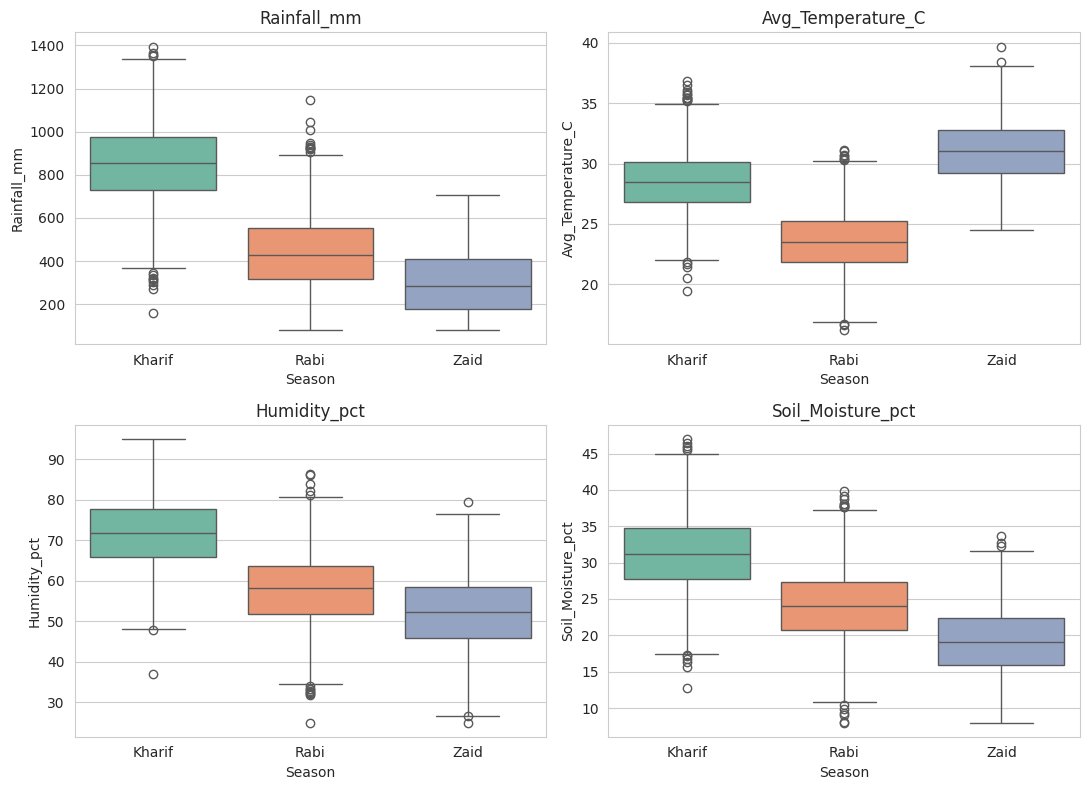

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, order=['Kharif','Rabi','Zaid'], ax=axes[i], palette='Set2')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


Kharif is the wettest and most humid season; Zaid is the hottest and driest; Rabi sits in between. This matches real seasonal agricultural patterns.

## 5. Resource Usage Across Seasons

In [12]:
res_cols = ['Fertilizer_kg_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
df.groupby('Season')[res_cols].median().reindex(['Kharif','Rabi','Zaid']).round(2)


,Fertilizer_kg_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,
Kharif,188.20,4469.0,3.28
Rabi,185.30,4292.0,2.74
Zaid,183.95,4805.0,2.30


/tmp/ipykernel_474/3951796762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=['Kharif','Rabi','Zaid'], ax=axes[i], palette='Set3', showfliers=False)
/tmp/ipykernel_474/3951796762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=['Kharif','Rabi','Zaid'], ax=axes[i], palette='Set3', showfliers=False)
/tmp/ipykernel_474/3951796762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=['Kharif','Rabi','Zaid'], ax=axes[i], palette='Set3', s

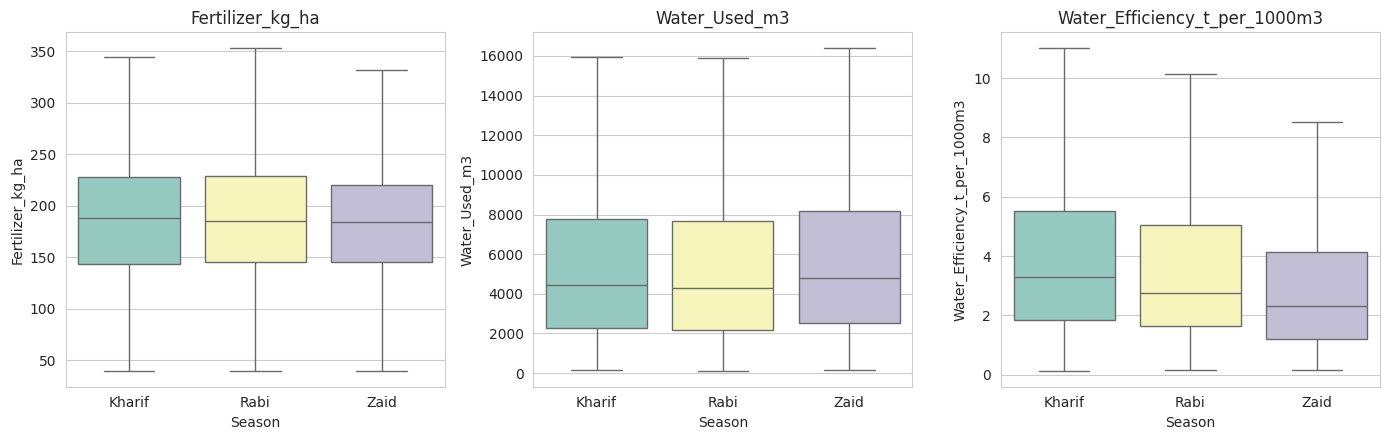

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for i, col in enumerate(res_cols):
    sns.boxplot(data=df, x='Season', y=col, order=['Kharif','Rabi','Zaid'], ax=axes[i], palette='Set3', showfliers=False)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


Water usage is highest in Kharif and Zaid, but Rabi shows better water efficiency (more tonnes produced per 1000 m³).

## 6. Yield Across Seasons

In [14]:
df.groupby('Season')['Yield_Tonnes_Ha'].agg(['mean','median']).reindex(['Kharif','Rabi','Zaid']).round(2)


,mean,median
Season,,
Kharif,5.63,1.95
Rabi,5.09,1.66
Zaid,4.64,1.45


/tmp/ipykernel_474/2338378549.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=['Kharif','Rabi','Zaid'], palette='YlGnBu', showfliers=False)


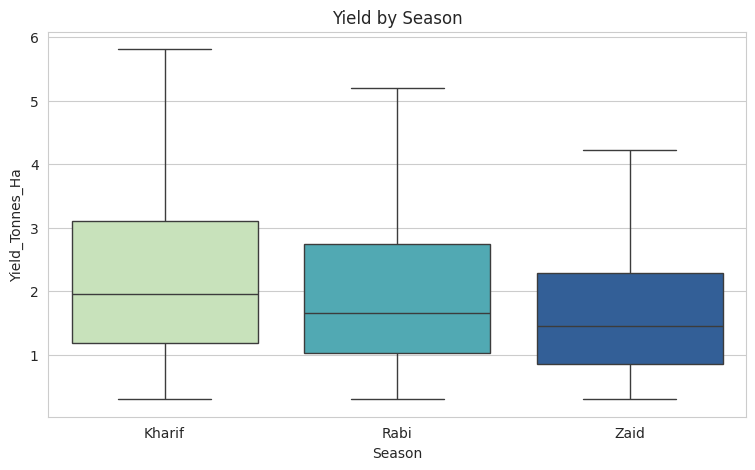

In [15]:
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=['Kharif','Rabi','Zaid'], palette='YlGnBu', showfliers=False)
plt.title('Yield by Season')
plt.show()


In [16]:
# Statistical test: is the yield difference across seasons significant?
groups = [df[df['Season']==s]['Yield_Tonnes_Ha'] for s in ['Kharif','Rabi','Zaid']]
f_stat, p_value = stats.f_oneway(*groups)
print(f'ANOVA p-value: {p_value:.5f}')
print('Significant difference' if p_value < 0.05 else 'No significant difference')


ANOVA p-value: 0.23285
No significant difference


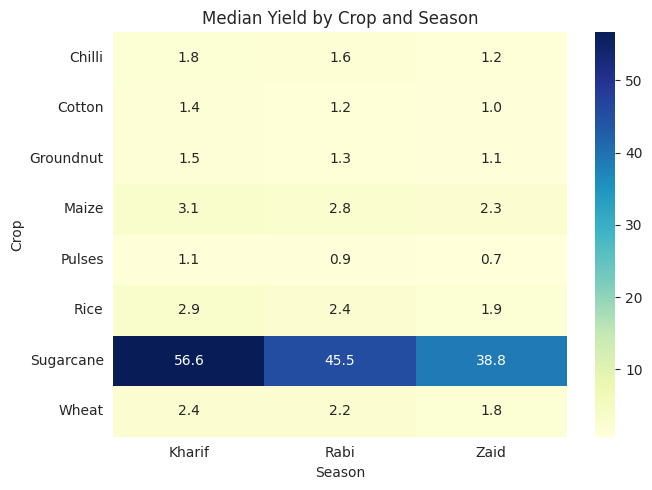

In [17]:
pivot_yield = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='median')[['Kharif','Rabi','Zaid']]
plt.figure(figsize=(7,5))
sns.heatmap(pivot_yield, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Median Yield by Crop and Season')
plt.tight_layout()
plt.show()


Sugarcane yields far more than any other crop in every season. For most other crops, crop type matters more than season for yield.

## 7. Economic Performance Across Seasons

In [18]:
df.groupby('Season')[['Profit_INR']].median().reindex(['Kharif','Rabi','Zaid'])


,Profit_INR
Season,
Kharif,38808.0
Rabi,-3187.0
Zaid,-62144.0


/tmp/ipykernel_474/2011431407.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', order=['Kharif','Rabi','Zaid'], palette='RdYlGn', showfliers=False)


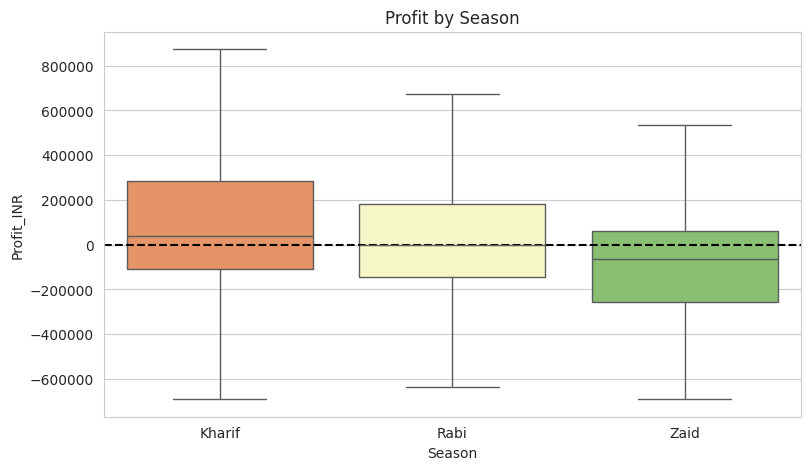

In [19]:
sns.boxplot(data=df, x='Season', y='Profit_INR', order=['Kharif','Rabi','Zaid'], palette='RdYlGn', showfliers=False)
plt.axhline(0, color='black', linestyle='--')
plt.title('Profit by Season')
plt.show()


In [20]:
loss_pct = df.groupby('Season')['Is_Loss_Making'].mean().reindex(['Kharif','Rabi','Zaid']) * 100
print('% of farms running at a loss, by season:')
print(loss_pct.round(1))
print('\nOverall % loss-making:', round(df['Is_Loss_Making'].mean()*100, 1))


% of farms running at a loss, by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Is_Loss_Making, dtype: float64

Overall % loss-making: 49.2


In [21]:
groups_p = [df[df['Season']==s]['Profit_INR'] for s in ['Kharif','Rabi','Zaid']]
f_stat2, p_value2 = stats.f_oneway(*groups_p)
print(f'ANOVA p-value: {p_value2:.5f}')
print('Significant difference' if p_value2 < 0.05 else 'No significant difference')


ANOVA p-value: 0.00000
Significant difference


Nearly half of all farms are loss-making overall, and **Zaid season has the highest share of loss-making farms** — lower rainfall pushes up irrigation costs without a matching gain in yield or price.

## 8. Relationships Between Variables

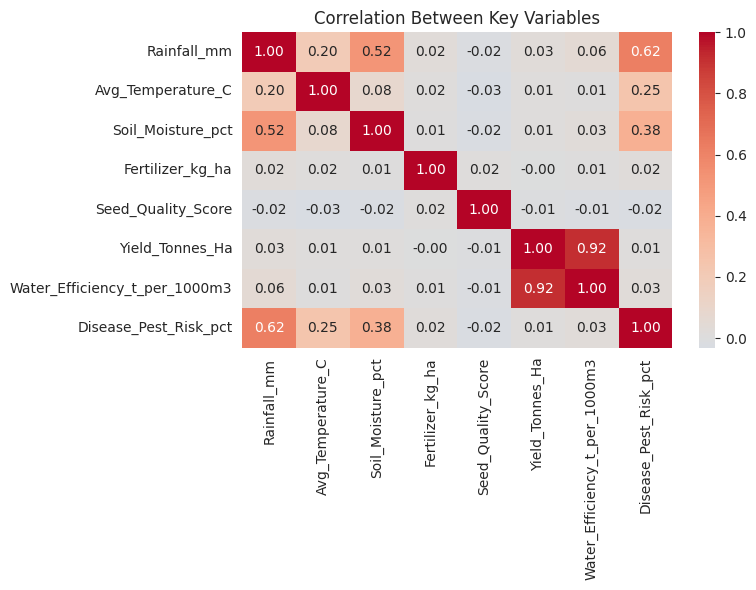

In [22]:
numeric_cols = ['Rainfall_mm','Avg_Temperature_C','Soil_Moisture_pct','Fertilizer_kg_ha',
                'Seed_Quality_Score','Yield_Tonnes_Ha','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Key Variables')
plt.tight_layout()
plt.show()


No single variable strongly drives yield on its own. Seed quality and water efficiency show the strongest positive relationship with yield; disease/pest risk shows a negative one.

## 9. Disease/Pest Risk by Season

/tmp/ipykernel_474/1171719148.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=['Kharif','Rabi','Zaid'], palette='OrRd')


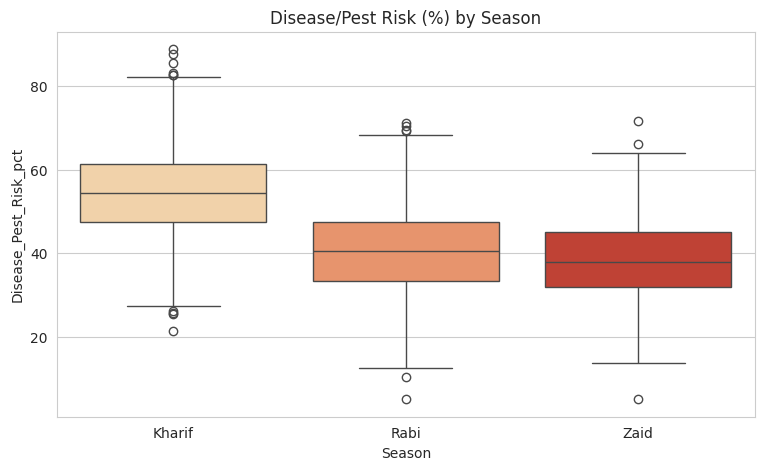

In [23]:
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=['Kharif','Rabi','Zaid'], palette='OrRd')
plt.title('Disease/Pest Risk (%) by Season')
plt.show()


Risk is highest in Kharif, matching the higher humidity and rainfall of the monsoon season.

## 10. Key Findings

1. Environmental conditions follow expected seasonal patterns — Kharif is wettest/most humid, Zaid is hottest/driest, Rabi is in between.
2. Yield differs significantly across seasons (ANOVA, p < 0.05), but crop type matters more than season for most crops.
3. Nearly 49% of farms are loss-making overall; **Zaid is the most financially vulnerable season**.
4. Water usage is highest in Kharif/Zaid, but Rabi shows better water efficiency.
5. Disease/pest risk is highest in Kharif due to humidity and rainfall.
6. No single input strongly predicts yield alone; seed quality and water efficiency are the most actionable levers.


## 11. Recommendations

- Prioritize support (irrigation subsidies, drought-resistant seeds) for Zaid season, where loss rates are highest.
- Invest in seed quality and water-use efficiency, the strongest positive drivers of yield found here.
- Strengthen pest/disease management ahead of Kharif season.
- Encourage efficient irrigation (Drip/Sprinkler) over Flood irrigation, especially in low-rainfall seasons.


## 12. Conclusion

Seasonal differences in environmental conditions, resource usage, yield and profitability are all statistically significant in this dataset. The most important finding is that profitability — not just yield — is the real seasonal challenge, with the Zaid season being the most financially at risk. These insights can support more evidence-based, season-specific agricultural planning.
